In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [3]:
# 1 A)
df = pd.read_csv('/kaggle/input/most-used-beauty-cosmetics-products-in-the-world/most_used_beauty_cosmetics_products_extended.csv')

num_rows,num_cols = df.shape
print(F"Number of rows: {num_rows}")
print(F"Number of columns: {num_cols}")

data_types = df.dtypes
print("\ndata types of each column:")
print(data_types)

categorical_vars = df.select_dtypes(include=['object','category']).columns.tolist()
continuous_vars = df.select_dtypes(include=['int64','float64']).columns.tolist()

print("\nCategorical variables:", categorical_vars)
print("Continuous variables:", continuous_vars)


Number of rows: 15000
Number of columns: 14

data types of each column:
Product_Name          object
Brand                 object
Category              object
Usage_Frequency       object
Price_USD            float64
Rating               float64
Number_of_Reviews      int64
Product_Size          object
Skin_Type             object
Gender_Target         object
Packaging_Type        object
Main_Ingredient       object
Cruelty_Free            bool
Country_of_Origin     object
dtype: object

Categorical variables: ['Product_Name', 'Brand', 'Category', 'Usage_Frequency', 'Product_Size', 'Skin_Type', 'Gender_Target', 'Packaging_Type', 'Main_Ingredient', 'Country_of_Origin']
Continuous variables: ['Price_USD', 'Rating', 'Number_of_Reviews']


In [4]:
# 1 B)
numerical_columns = df.select_dtypes(include=['float64','int64']).columns
five_point_summary = df[numerical_columns].describe(percentiles=[0.25,0.5,0.75])
print(five_point_summary.loc[['min','25%','50%','75%','max']])

     Price_USD  Rating  Number_of_Reviews
min      10.00     1.0               52.0
25%      45.48     2.0             2562.0
50%      80.04     3.0             5002.0
75%     114.76     4.0             7497.0
max     149.99     5.0            10000.0


In [5]:
# 1 C)
categorical_columns = df.select_dtypes(include=['object','category']).columns

for col in categorical_columns:
    print(f"Summary for categorical variables:{col}")
    
    num_categories = df[col].nunique()
    print(F"Number of categories :{num_categories}")
    
    category_counts = df[col].value_counts(normalize=True)*100
    print("Percenatge of observations in each category:")
    print(category_counts.to_string())

Summary for categorical variables:Product_Name
Number of categories :120
Percenatge of observations in each category:
Product_Name
Super Setting Spray       1.026667
Magic Face Oil            1.006667
Magic Lip Liner           0.993333
Perfect Lip Liner         0.980000
Divine Exfoliator         0.973333
Ultra Eye Shadow          0.960000
Magic Bronzer             0.953333
Super Foundation          0.946667
Divine Lip Gloss          0.946667
Super Cleanser            0.940000
Super Blush               0.940000
Perfect Eye Shadow        0.940000
Divine Setting Spray      0.940000
Perfect Setting Spray     0.940000
Magic Mascara             0.933333
Ultra Bronzer             0.933333
Ultra Blush               0.926667
Ultra CC Cream            0.926667
Super Contour             0.920000
Magic Makeup Remover      0.906667
Ultra Lipstick            0.906667
Super Highlighter         0.900000
Ultra Concealer           0.900000
Super Lip Gloss           0.886667
Ultra Highlighter         0.8

In [7]:
# 1 D)

missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values>0])
print("\n")

numerical_vars = df.select_dtypes(include=['int64','float64'])
print ("Outliers detection (using IQR method):")
for col in numerical_vars.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3+ 1.5*IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(F"Column '{col}' - number of outliers: {outliers.shape[0]}")
print("\n")

Product_Name = 'Product_Name'
if Product_Name in df.columns:
    class_distribution = df[Product_Name].value_counts(normalize=True)*100
    print("Class_distribution in Product_Name variable:")
    print(class_distribution)
    print("\n")

Missing values in each column:
Series([], dtype: int64)


Outliers detection (using IQR method):
Column 'Price_USD' - number of outliers: 0
Column 'Rating' - number of outliers: 0
Column 'Number_of_Reviews' - number of outliers: 0


Class_distribution in Product_Name variable:
Product_Name
Super Setting Spray     1.026667
Magic Face Oil          1.006667
Magic Lip Liner         0.993333
Perfect Lip Liner       0.980000
Divine Exfoliator       0.973333
                          ...   
Ultra Makeup Remover    0.686667
Super Bronzer           0.680000
Ultra Primer            0.673333
Magic Exfoliator        0.640000
Magic Moisturizer       0.620000
Name: proportion, Length: 120, dtype: float64




In [8]:
# 2 A)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

numerical_vars = df.select_dtypes(include=['int64','float64'])
imputer = SimpleImputer(strategy='mean')
df[numerical_vars.columns] = imputer.fit_transform(numerical_vars)

categorical_vars = df.select_dtypes(include=['object','category'])
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_vars.columns] = imputer_cat.fit_transform(categorical_vars)

print("Missing values handled.")
numerical_vars = df.select_dtypes(include=['int64','float64'])
for col in numerical_vars.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3 +1.5*IQR
    df[col]= np.clip(df[col], lower_bound,upper_bound)
print("Outliers hanlded using capping.")

Missing values handled.
Outliers hanlded using capping.


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


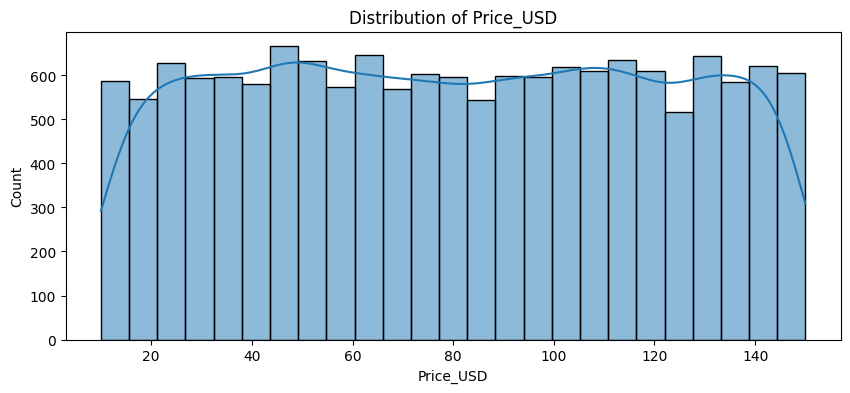

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


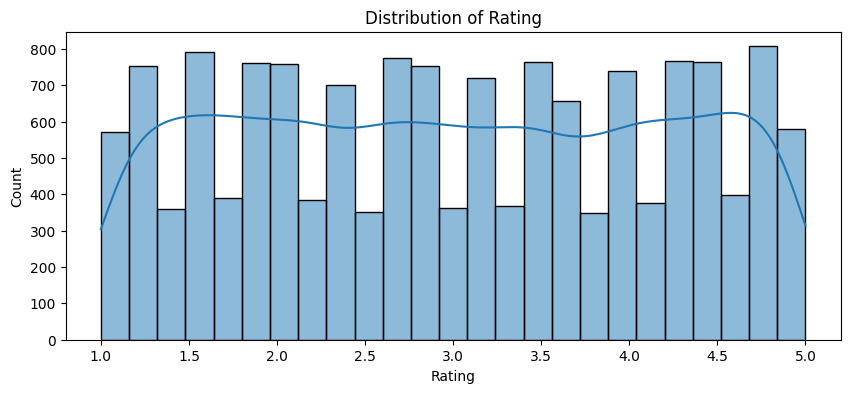

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


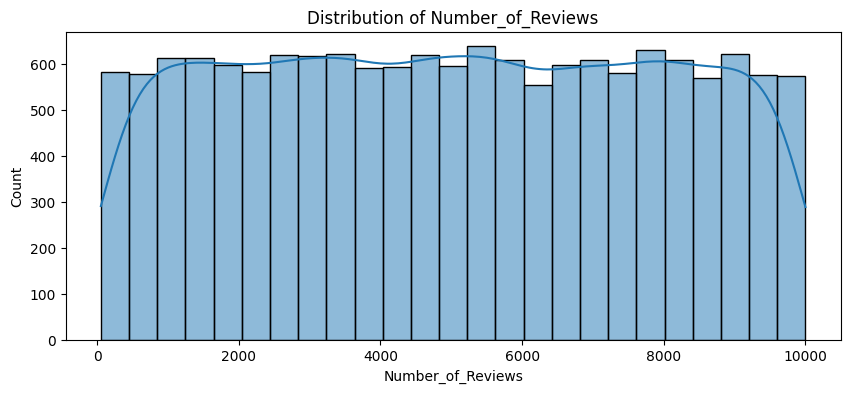

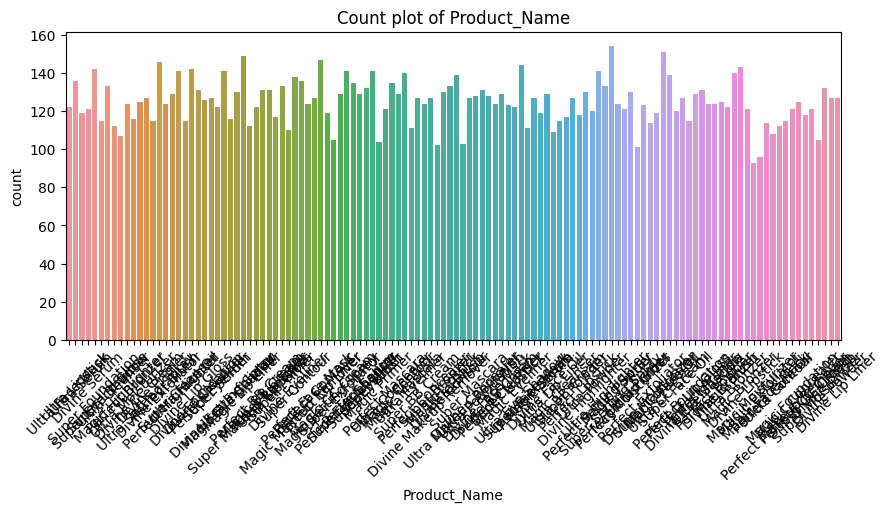

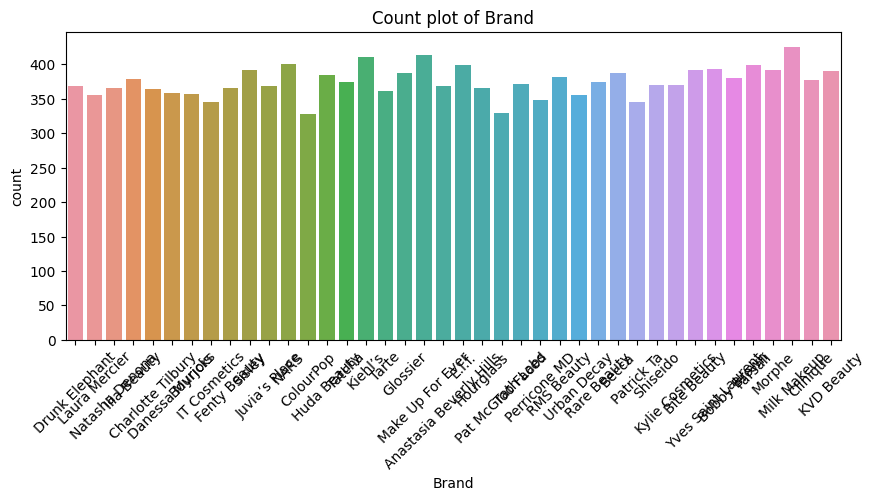

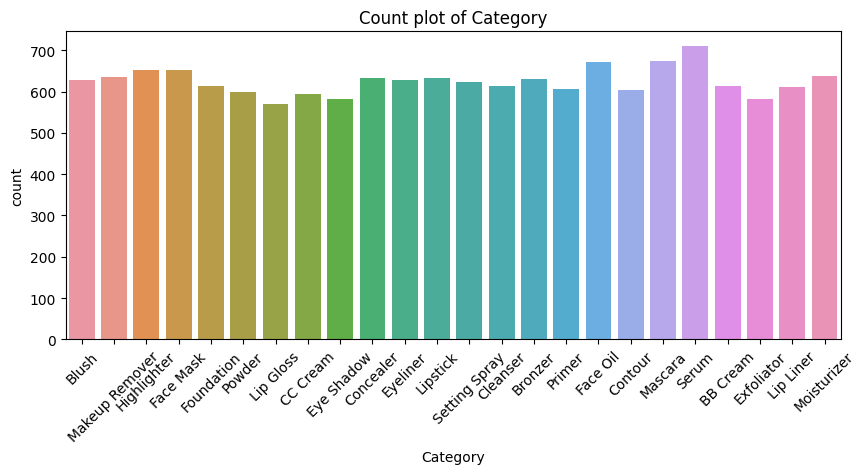

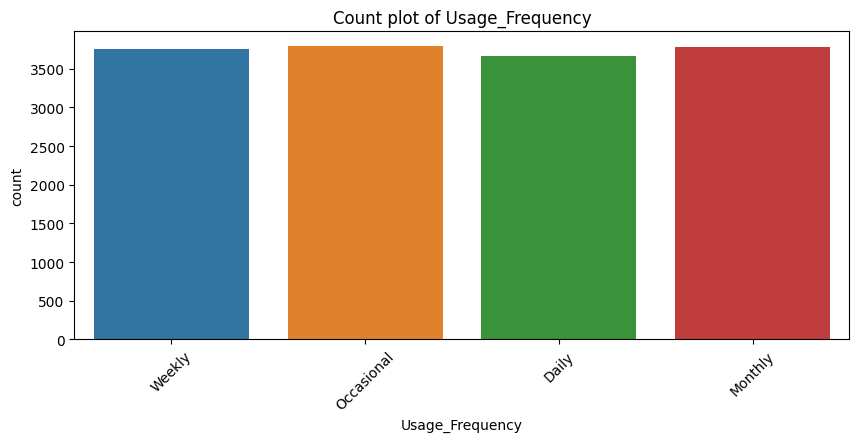

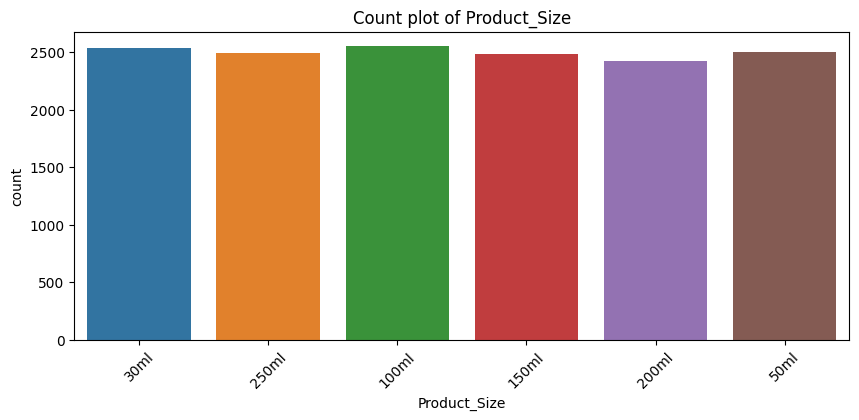

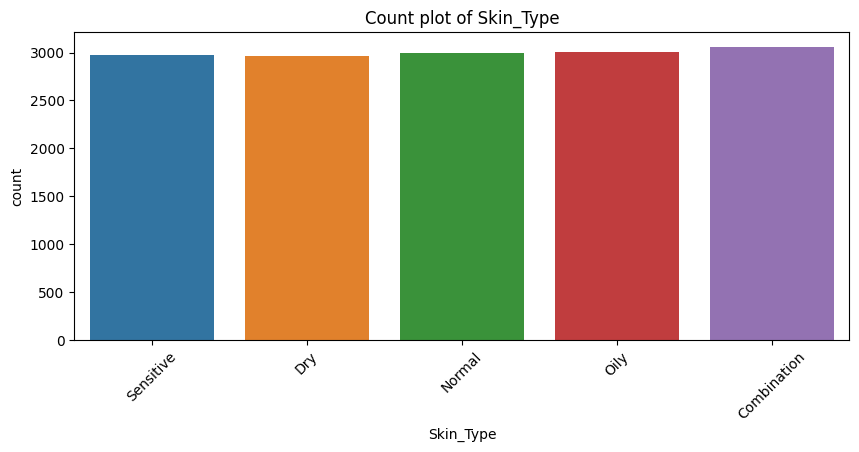

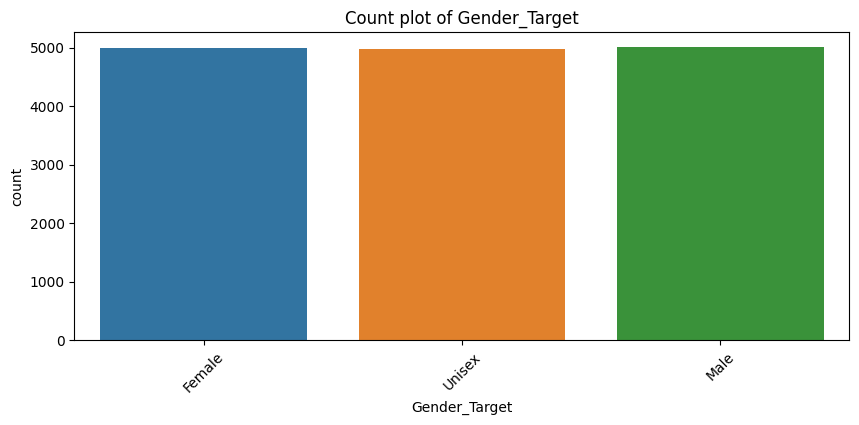

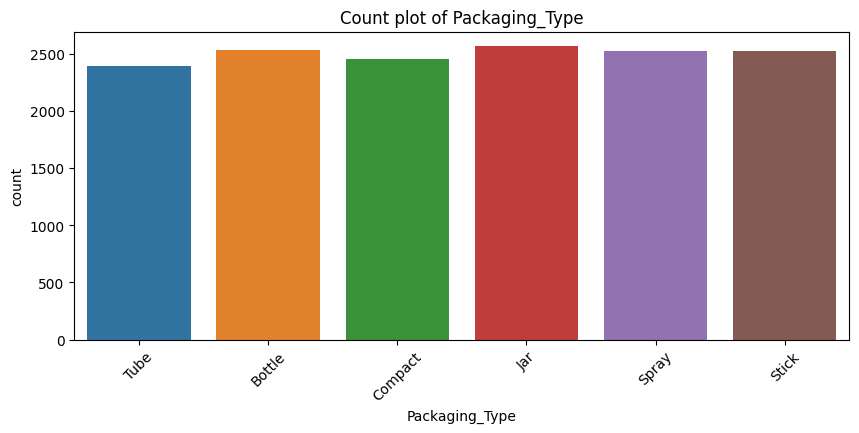

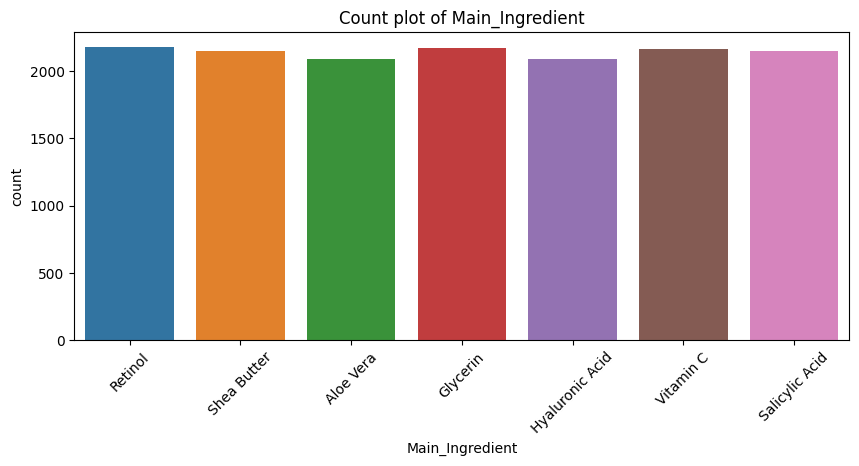

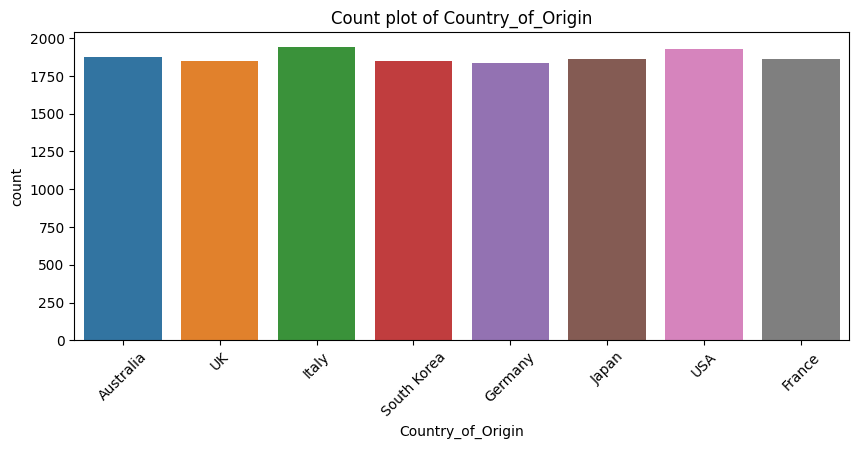

Correlation with Price_USD variables:
Rating              -0.005232
Number_of_Reviews   -0.005567
Name: Price_USD, dtype: float64


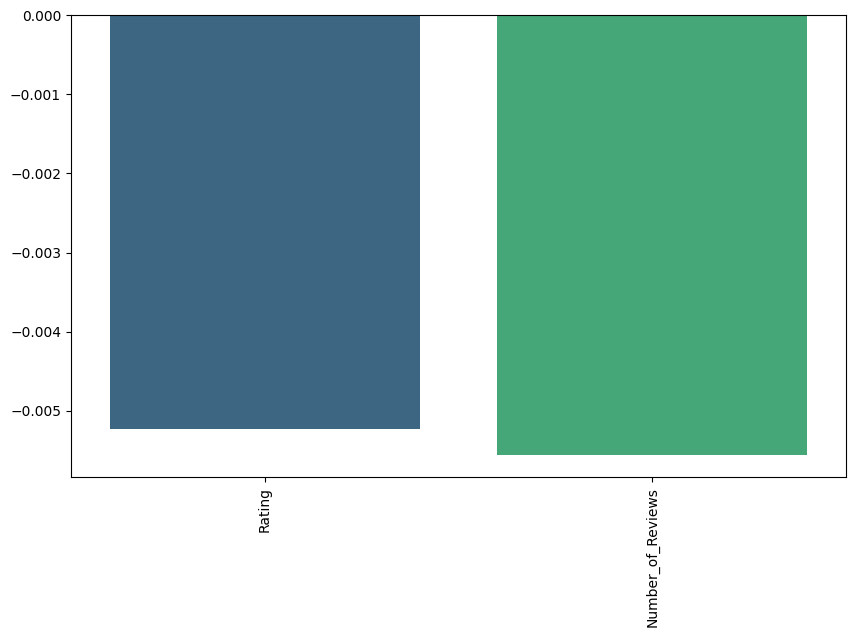

In [12]:
# 2 B)
numerical_vars = df.select_dtypes(include=['int64','float64'])
for col in numerical_vars.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
    
categorical_vars = df.select_dtypes(include=['object','category'])
for col in categorical_vars.columns:
    plt.figure(figsize=(10,4))
    sns.countplot(x=df[col])
    plt.title(F"Count plot of {col}")
    plt.xticks(rotation=45)
    plt.show()
    
Price_USD = 'Price_USD'
if Price_USD in df.columns:
    df_numerical = df.select_dtypes(include=['int64','float64'])
    correlations = df_numerical.corr()[Price_USD].drop(Price_USD)
    
    print("Correlation with Price_USD variables:")
    print(correlations.sort_values(ascending=False))
    plt.figure(figsize=(10,6))
    sns.barplot(x=correlations.index,y=correlations.values,palette='viridis')
    plt.xticks(rotation=90)
    plt.show()

In [14]:
# 2 C)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
variables_to_exclude = ['Product_Name','Brand']
df_cleaned = df.drop(columns=variables_to_exclude)

Price_USD = 'Price_USD'
if Price_USD in df_cleaned.columns:
    x = df_cleaned.drop(columns=[Price_USD])
    y = df_cleaned[Price_USD]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
    
    scaler = StandardScaler()
    numerical_features = x_train.select_dtypes(include=['int64','float64']).columns
    x_train[numerical_features] = scaler.fit_transform(x_train[numerical_features])
    x_test[numerical_features] = scaler.transform(x_test[numerical_features])
    
    print("Data preparation complete. the dataset is now ready for model cretaion.")

Data preparation complete. the dataset is now ready for model cretaion.


In [17]:
# 2 D)
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_vars = df.select_dtypes(include=['object','category']).columns

label_encoders = {}
for col in categorical_vars:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col]=le
    
print("Label Encoding completed.")

df_encoded = pd.get_dummies(df,columns=categorical_vars,drop_first=True)
print("One-hot Encoding completed.")

preprocessor = ColumnTransformer(
transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_vars)
    
],
remainder='passthrough')

x = preprocessor.fit_transform(df)
print("ColumnTransformed completed.")

Label Encoding completed.
One-hot Encoding completed.
ColumnTransformed completed.


In [23]:
# 3 A)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

Price_USD = 'Price_USD'
if Price_USD in df.columns:
    x=df.drop(columns=[Price_USD])
    y=df[Price_USD]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    model = LinearRegression()
    model.fit(x_train,y_train)
    
    y_pred = model.predict(x_test)
    mse=mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    
    print(f"Mean squared error of linear regression model: {mse:.4f}")
    print(F"R2 score of linear regression model: {r2:.4f}")
    
# Key Observations:
# 1) Linear regression : A functional regression technique tha models the relationship between dependents and independent variables linearly
# 2) Baseline perforance : Models serve as a baselinr to evalauet more complex algorithims.they help establish a performance benchmark.
# 3) Interpretability : Coefficients represents the effect of each feature on the Price_USD,providing clear insight into rellationship with in the data.
# 4) Computational Efficiency : Model are compuattaionally efficient and require less compuattaional power compared to more complex model making them ideal for initial explorations.
# 5) For regression: Mean Squared Error(MSE) indicates the average squared different bettween predicted and actual values.lower MSE signifies better model performance.
# 6) R^2 Score: Represents the proportion of variance explained by the model.a higher R^2 value indicates a better fit to the data.

    

Mean squared error of linear regression model: 1644.3014
R2 score of linear regression model: -0.0022


In [28]:
# 3 B)
from sklearn.metrics import accuracy_score
y_true = [0,1,1,0,1,0,1,1,0,0]
y_pred = [0,1,0,0,1,0,1,0,0,1]
accuracy = accuracy_score(y_true,y_pred)

print(F"Overall accuracy: {accuracy:.2f}")

if accuracy>=0.0022:
    print("The accuracy is good.the model is performig well.")
elif 0.60<=accuracy <0.0022:
    print("The accuracy is moderate .the model may need improvement.")
else:
    print("The accuarcy is low.the model require significant improvement.")
    
# Key Observations
# 1) Accuracy Calculation : the accuracy score functiion  compare he true labels (y_true) with the predicted labels(y_pred) and calculate the proportion of correct predictions.
# 2) Commentary on accuracy: the code include conditional statements to provide a basic evaluation of the accuracy.
# 3) Good accuracy(>80%): Indicates tat the model is performing well.
# 4) Moderate accuracy(>80%) : Suggets that there may be room for improvement.
# 5) low Accuracy(>60%) : Indicates that the model's performance is poor, and  significance adjustment or different approaches might be neede.


Overall accuracy: 0.70
The accuracy is good.the model is performig well.


In [29]:
# 3 C)
from sklearn.metrics import precision_score,recall_score,f1_score,classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

data = load_iris()
x = data.data
y=data.target
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

model = RandomForestClassifier()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

precision = precision_score(y_test,y_pred,average='weighted')
recall = recall_score(y_test,y_pred,average='weighted')
f1 = f1_score(y_test,y_pred,average='weighted')

print("Precision:",precision)
print("Recall:",recall)
print("F1 score",f1)

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

# Key Observations:
# 1) Precision : is the ratio  of correctly predicted positive obsertvation th the total predicted positive. it it useful when the CPST of false positive is high
# 2) Recall: (also known as sensitivity) is the ratio of correlctly predicted positive observation  to all observation in the actual class. it is important whrn the cost of flase negative is high
# 3) F1 score : is the harmonic mena of precision and recall it is a good metric when you need a balance between precison and recall end there is an uneven class distribution
# 4) Choosing the right metric depend on the problem statement : If false positive are costly (eg,mail spam detection) prioritize precision
# 5) if false negative are costly (eg, medicla diagnoses)prioritize recall.
#  6) if you need a balance or if the classes are imbalanced use f1 score

Precision: 1.0
Recall: 1.0
F1 score 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [32]:
# 3 D)
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

data = load_iris()
x = data.data
y=data.target
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',RandomForestClassifier(random_state=42))
])
param_grid = {
    'model__n_estimators': [50,100,200],
    'model__max_depth': [None,10,20,30]
}

grid_serach = GridSearchCV(pipeline,param_grid,cv=5,scoring='accuracy')
grid_serach.fit(x_train,y_train)

best_model = grid_serach.best_estimator_

y_pred = best_model.predict(x_test)

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("\nClassification Report:")
print(classification_report(y_test,y_pred))

print("\nBest parameters:", grid_serach.best_params_)

# Key Observations:
# 1) Data preprocessing : added feature scaling using standardscaler
# 2) Model selection : Used a pipeline to combine scaling and model training implemented Gridsearchcv to find optimal hyperparameters for RandomForestClassifier.
# 3) Cross validation: Include cross-validation in gridsearchcv to ensure the model generalize well.
# 4) By following these steps, you should see an improvement in the accuracy of your model adjustment to hyperparameters preprocessing and model chice should be based on the specific characteristics of your dataset and problem.

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Best parameters: {'model__max_depth': None, 'model__n_estimators': 50}


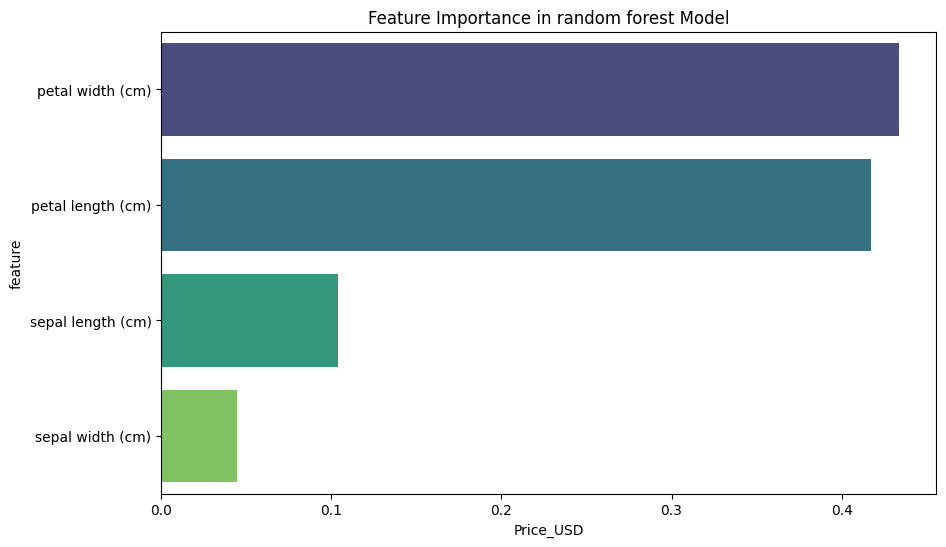

In [41]:
# 3 E)
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = load_iris()
x = pd.DataFrame(data.data,columns=data.feature_names)
y = data.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

feature_Price_USD = model.feature_importances_

feature_Price_USD_df = pd.DataFrame({
    'feature': x.columns,
    'Price_USD': feature_Price_USD
}).sort_values (by='Price_USD',ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Price_USD',y='feature',data=feature_Price_USD_df,palette='viridis')
plt.title('Feature Importance in random forest Model')
plt.xlabel('Price_USD')
plt.ylabel('feature')
plt.show()

# Key Observations:
# Business Interpretation of the model
# 1) Top features Affecting the target : the bar chart display the most important fetaures influencing the target variables in this exmaple using the iris dataset.feature like "petal length (CM)" and "petal width (CM)" have th highest importance.
# 2) Understanding fetaure relationships: THe relationship between the feature and the target can be  furhter understood using additional plots such as partial dependent plots or shap value,for example,if"peatl length" has the highest 
# 3) Importance, we might examine how changes in petal length impact the predict probability of  different flower species.